<a href="https://colab.research.google.com/github/rishabhucb/court-keypoints/blob/main/court_keypoints_day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/court_keypoints'
os.makedirs(PROJECT_DIR, exist_ok=True)
%cd {PROJECT_DIR}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/court_keypoints


In [20]:
!pip install -q roboflow ultralytics


In [21]:
from google.colab import userdata
from roboflow import Roboflow

api_key = userdata.get("ROBOFLOW_API_KEY")

print("Key loaded:", api_key is not None)

rf = Roboflow(api_key=api_key)

print("Roboflow authentication successful!")

Key loaded: True
Roboflow authentication successful!


In [22]:
from google.colab import userdata
from roboflow import Roboflow

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
ws = rf.workspace()          # no name = the workspace your API key belongs to
print("Workspace ID:", ws.url)
print("Projects:")
for p in ws.projects():
    print("  ", p)

loading Roboflow workspace...
Workspace ID: rishabh-ucb-gmail-com
Projects:
   rishabh-ucb-gmail-com/basketball-court-keypoints-l4d5o-puuiw
   rishabh-ucb-gmail-com/basketball-players-and-ball-a6fnk
   rishabh-ucb-gmail-com/nextrun-court-keypoints


In [23]:
project = rf.workspace("rishabh-ucb-gmail-com").project("basketball-court-keypoints-l4d5o-puuiw")
dataset = project.version(1).download("yolov8")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...
/content/drive/MyDrive/court_keypoints/basketball-court-keypoints-1


In [24]:
!cat {dataset.location}/data.yaml
!ls {dataset.location}
!ls {dataset.location}/train/images | wc -l
!ls {dataset.location}/valid/images | wc -l
!ls {dataset.location}/test/images  | wc -l

flip_idx:
- 0
- 1
- 2
- 6
- 5
- 4
- 3
- 8
- 7
- 9
- 11
- 10
- 12
kpt_shape:
- 13
- 3
names:
- basketball_court
nc: 1
roboflow:
  license: CC BY 4.0
  project: basketball-court-keypoints-l4d5o-puuiw
  url: https://app.roboflow.com/rishabh-ucb-gmail-com/basketball-court-keypoints-l4d5o-puuiw/1
  version: 1
  workspace: rishabh-ucb-gmail-com
test: ../test/images
train: ../train/images
val: ../valid/images
data.yaml  README.roboflow.txt	test  train  valid
150
22
12


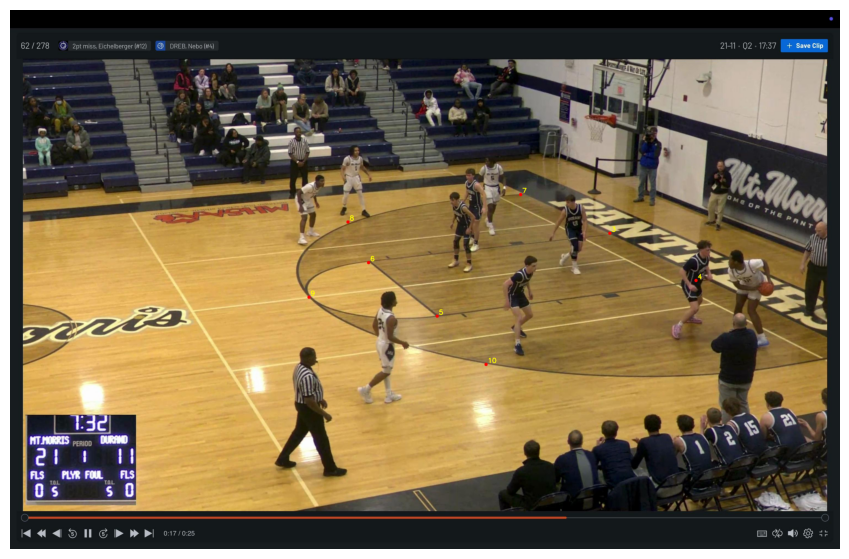

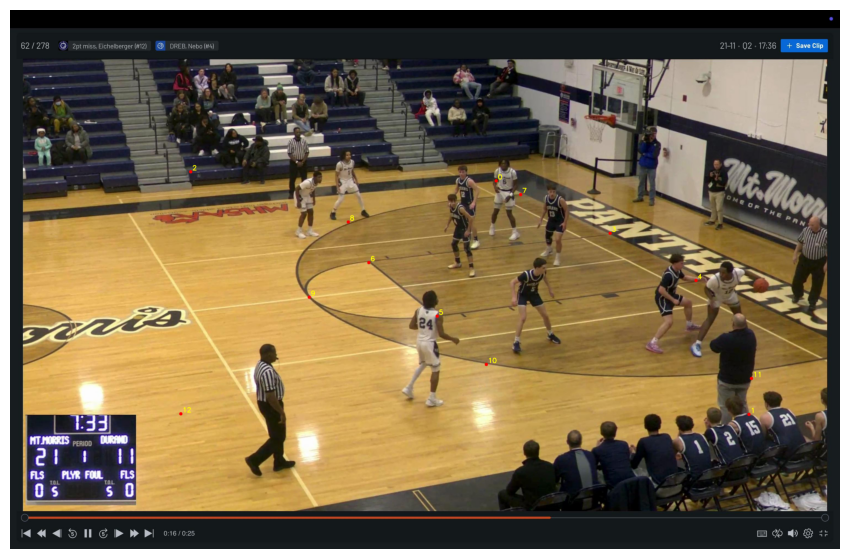

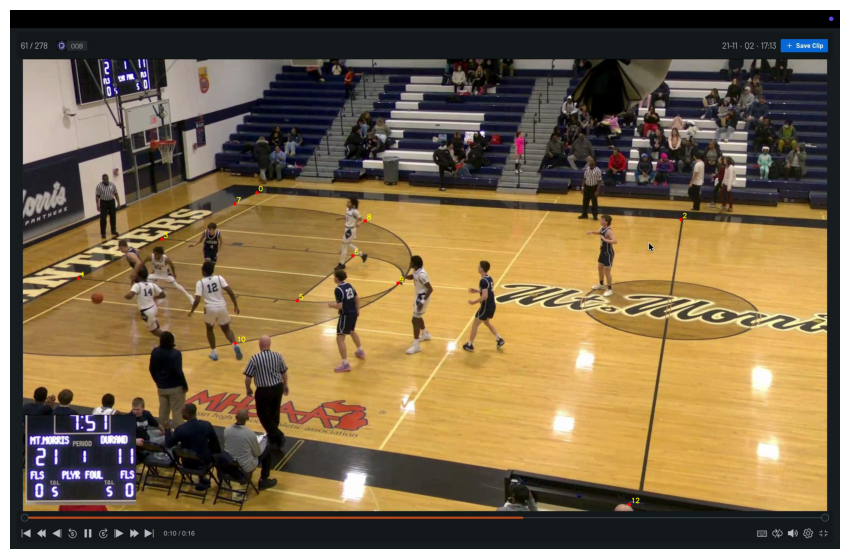

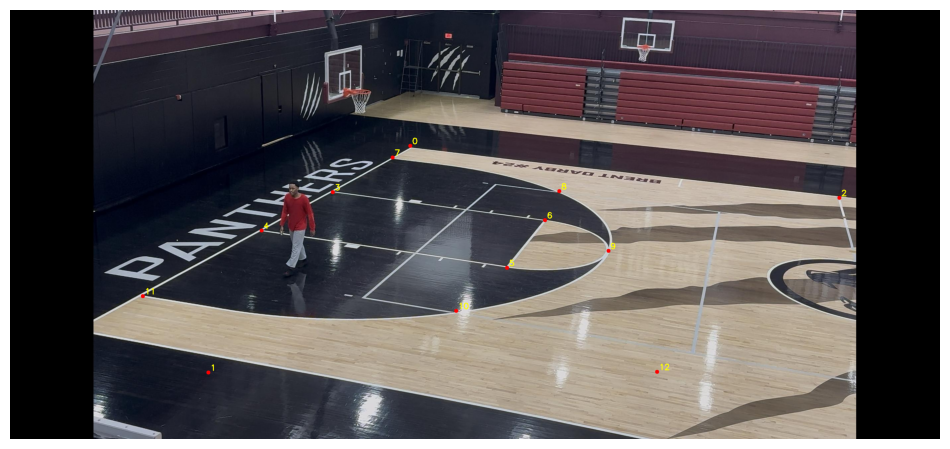

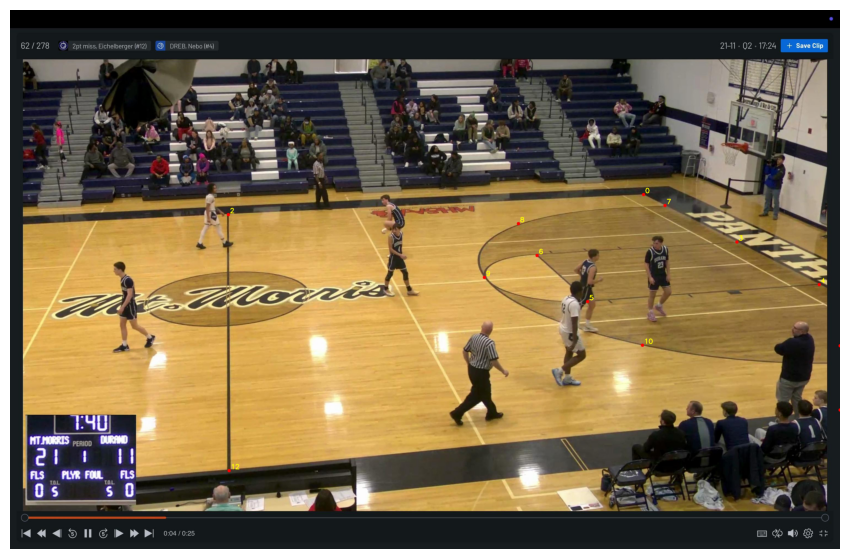

...

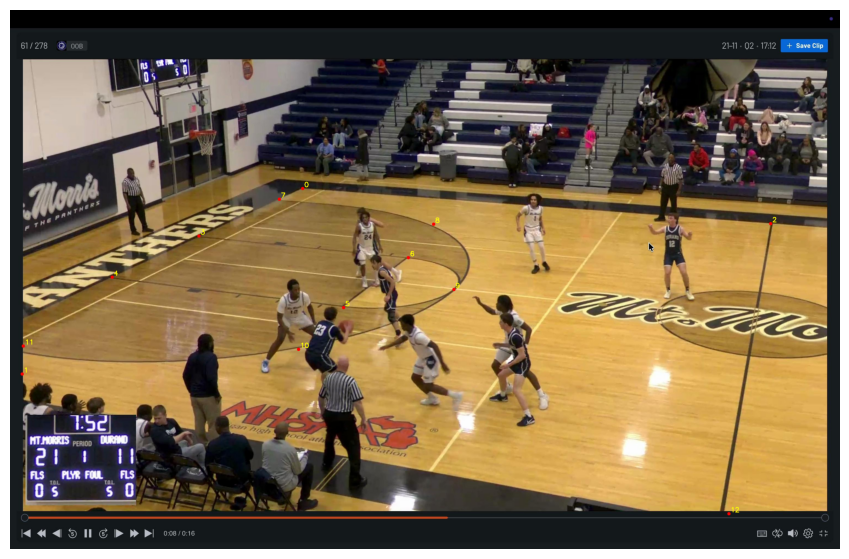

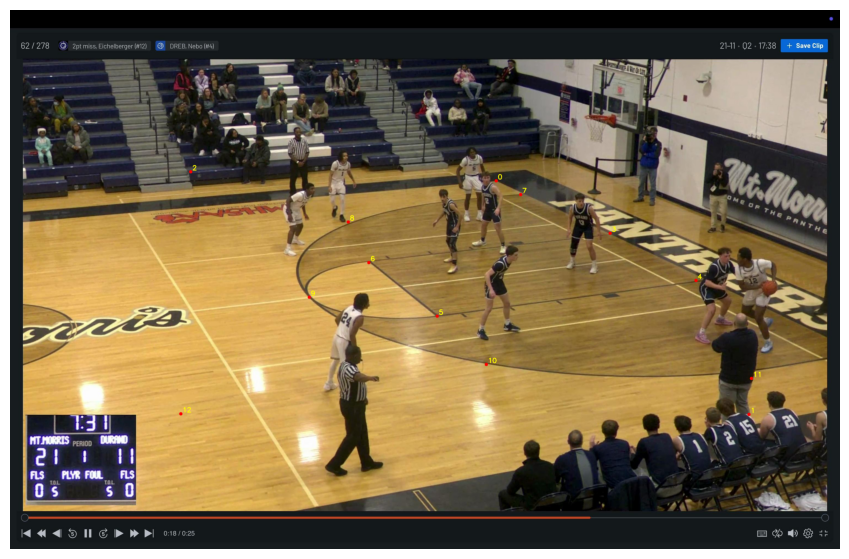

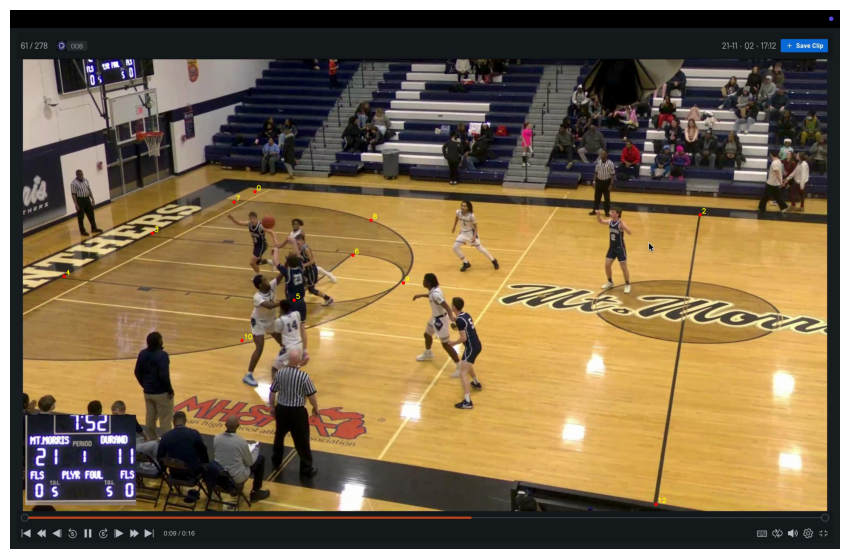

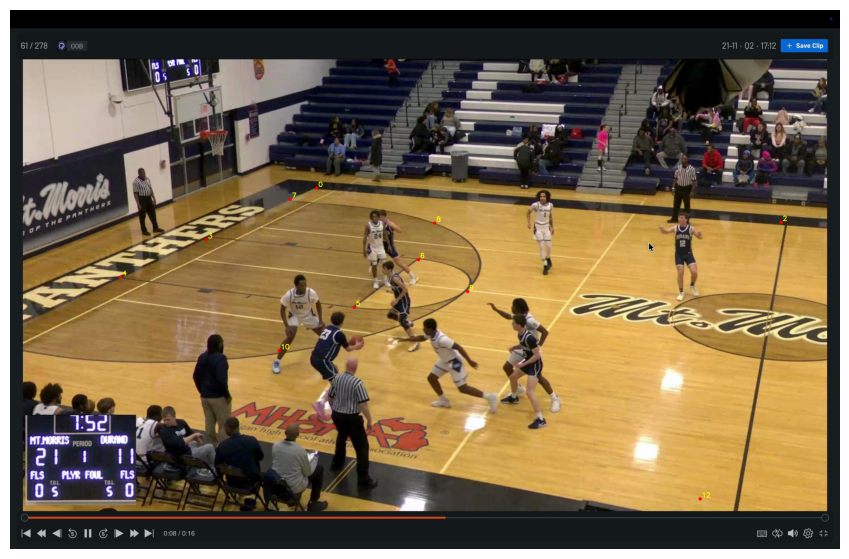

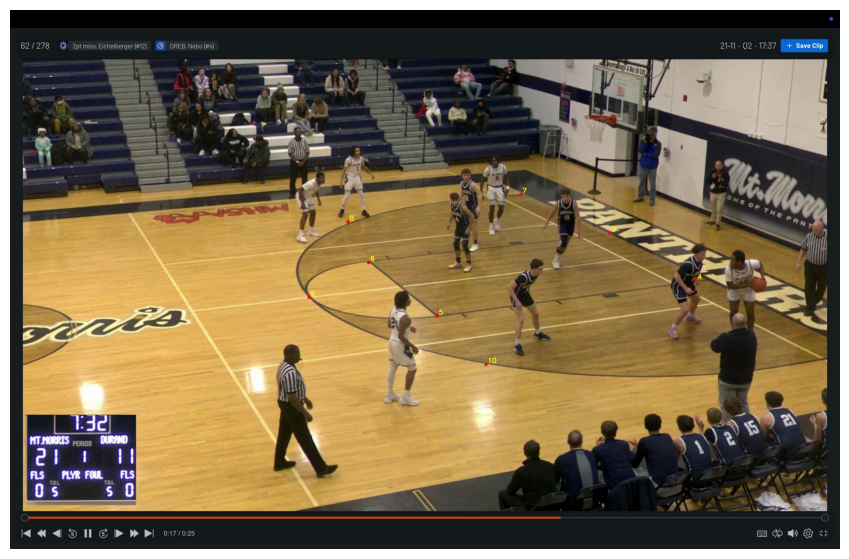

In [28]:
import cv2, glob, random, yaml
import matplotlib.pyplot as plt

cfg = yaml.safe_load(open(f'{dataset.location}/data.yaml'))
n_kpts, kdim = cfg['kpt_shape']

def show(img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    for line in open(lbl):
        v = list(map(float, line.split()))
        kpts = v[5:]                       # skip class + box
        for i in range(n_kpts):
            x, y = kpts[i*kdim] * w, kpts[i*kdim + 1] * h
            vis = kpts[i*kdim + 2] if kdim == 3 else 1
            if vis > 0:
                cv2.circle(img, (int(x), int(y)), 6, (255, 0, 0), -1)
                cv2.putText(img, str(i), (int(x)+6, int(y)-6),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    plt.figure(figsize=(12, 7)); plt.imshow(img); plt.axis('off'); plt.show()

imgs = glob.glob(f'{dataset.location}/train/images/*')
for p in random.sample(imgs, 20):
    show(p)